<a href="https://colab.research.google.com/github/cem8kaya/5G-LLM-ENGINE/blob/main/C%2B%2B_SLM_v1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sıfırdan Küçük Dil Modeli (SLM) Geliştirme - Sürüm 1.1

## Bölüm 0 — Proje Tanıtımı ve v1.1 Güncellemeleri

Bu notebook, **v1.0** üzerine inşa edilmiş daha gelişmiş bir "Küçük Dil Modeli" (Small Language Model) projesidir.

### ✨ v1.1 ile Gelen Yenilikler:
1. **Gelişmiş Çıkarım (Sampling):** Sadece en yüksek olasılıklı kelimeyi (Greedy) seçmek yerine, insan benzeri üretim sağlayan `Temperature` ve `Top-K` algoritmaları eklendi.
2. **Ağırlık İlklendirmesi (Weight Initialization):** PyTorch modelinin daha hızlı ve kararlı öğrenmesi için özel ilklendirme stratejileri eklendi.
3. **Tokenizer Entegrasyonu:** Eğitilen Tokenizer'ın sözlüğü (Vocabulary) dışa aktarılarak C++ motorunun metin üretebilmesi sağlandı.
4. **Gelişmiş C++ Motoru:** C++ motoruna gerçek bir üretim döngüsü (Generation Loop) iskeleti ve Vocabulary okuma yeteneği eklendi.

**Hedef:** PyTorch'ta eğitilen bir Transformer'ın zihnini alıp, saf C++ ile konuşmasını sağlamak.

## Bölüm 1 — Ortam Kurulumu ve Bağımlılıklar

Gerekli kütüphaneleri yüklüyor ve GPU'yu aktif ediyoruz.

In [1]:
!pip install -q torch transformers datasets tokenizers sentencepiece ninja cmake pyyaml matplotlib

import torch
import os
import time

print("=== ORTAM KONTROLÜ (v1.1) ===")
print(f"PyTorch Versiyonu: {torch.__version__}")
print(f"CUDA (GPU) Erişimi: {'Aktif' if torch.cuda.is_available() else 'PASİF - Lütfen Runtime tipini GPU yapın!'}")
if torch.cuda.is_available():
    print(f"GPU Cihazı: {torch.cuda.get_device_name(0)}")

# Proje dosya yapısını oluşturalım
dirs = ["slm_project/data", "slm_project/models", "slm_project/cpp"]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("Klasör yapısı oluşturuldu. Ortam hazır.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.7 MB/s eta 0:00:00
=== ORTAM KONTROLÜ (v1.1) ===
PyTorch Versiyonu: 2.11.0+cu128
CUDA (GPU) Erişimi: Aktif
GPU Cihazı: Tesla T4
Klasör yapısı oluşturuldu. Ortam hazır.


## Bölüm 2 — Proje Konfigürasyonunun (Hyperparameters) Tanımlanması

v1.1 Notu: Daha hızlı prototipleme için `d_model` ve `n_layers` değerlerini Colab T4 GPU'suna optimum uyacak şekilde yapılandırdık.

In [2]:
import yaml

config = {
    "model": {
        "vocab_size": 4096,      # Kelime dağarcığı
        "d_model": 128,          # Vektör boyutu
        "n_layers": 4,           # Transformer bloğu sayısı
        "n_heads": 4,            # Attention head sayısı
        "max_seq_len": 256       # Maksimum bağlam uzunluğu
    },
    "training": {
        "batch_size": 64,        # V1.1: Batch size artırıldı (daha stabil gradientler)
        "learning_rate": 1e-3,   # V1.1: LR artırıldı (daha hızlı öğrenme)
        "max_iters": 1000,       # Zaman kazanmak için 1000 adım
        "eval_interval": 200
    }
}

with open("slm_project/config.yaml", "w") as f:
    yaml.dump(config, f)

print("Konfigürasyon 'slm_project/config.yaml' dosyasına kaydedildi.")

Konfigürasyon 'slm_project/config.yaml' dosyasına kaydedildi.


## Bölüm 3 & 4 — Veri Toplama ve Temizleme Boru Hattı

TinyStories veri setinin minik bir kısmını indiriyoruz.

In [3]:
from datasets import load_dataset
import re

print("TinyStories veri seti indiriliyor...")
dataset = load_dataset("roneneldan/TinyStories", split="train[:2%]")

def clean_text(example):
    text = example['text'].lower()
    text = re.sub(r'[^a-z0-9\s.,!?]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return {"text": text}

cleaned_dataset = dataset.map(clean_text, num_proc=2)
print(f"\nToplam Hikaye Sayısı: {len(cleaned_dataset)}")

TinyStories veri seti indiriliyor...


README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

...

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/42394 [00:00<?, ? examples/s]


Toplam Hikaye Sayısı: 42394


## Bölüm 5 — Tokenizer Eğitimi ve Dışa Aktarımı

**v1.1 Geliştirmesi:** Tokenizer'ı sadece JSON olarak değil, C++'ın kolayca okuyabileceği `vocab.txt` formatında da kaydediyoruz.

In [4]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"],
    vocab_size=config['model']['vocab_size']
)

def batch_iterator(batch_size=1000):
    for i in range(0, len(cleaned_dataset), batch_size):
        yield cleaned_dataset[i : i + batch_size]["text"]

print("Tokenizer eğitiliyor...")
tokenizer.train_from_iterator(batch_iterator(), trainer=trainer)
tokenizer.save("slm_project/tokenizer.json")

# --- v1.1 YENİLİK: C++ için Vocab Export ---
vocab = tokenizer.get_vocab()
sorted_vocab = sorted(vocab.items(), key=lambda x: x[1]) # ID'ye göre sırala

with open("slm_project/models/vocab.txt", "w", encoding="utf-8") as f:
    for token, idx in sorted_vocab:
        # C++'ta okuması kolay olsun diye özel karakterleri değiştiriyoruz
        token_clean = token.replace("\n", "\\n").replace("\r", "\\r")
        f.write(f"{token_clean}\n")

print("Tokenizer başarıyla eğitildi.")
print("C++ motoru için vocab.txt başarıyla dışa aktarıldı!")

Tokenizer eğitiliyor...
Tokenizer başarıyla eğitildi.
C++ motoru için vocab.txt başarıyla dışa aktarıldı!


## Bölüm 6 — Dataloader

In [5]:
from torch.utils.data import Dataset, DataLoader
import torch

class SLMDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len):
        self.data = hf_dataset
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.pad_id = tokenizer.token_to_id("[PAD]")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]['text']
        encoded = self.tokenizer.encode(text).ids

        target_len = self.max_len + 1
        if len(encoded) > target_len:
            encoded = encoded[:target_len]
        else:
            encoded = encoded + [self.pad_id] * (target_len - len(encoded))

        x = torch.tensor(encoded[:-1], dtype=torch.long)
        y = torch.tensor(encoded[1:], dtype=torch.long)
        return x, y

train_ds = SLMDataset(cleaned_dataset, tokenizer, config['model']['max_seq_len'])
train_loader = DataLoader(train_ds, batch_size=config['training']['batch_size'], shuffle=True, drop_last=True)

## Bölüm 7 & 8 — Transformer Mimarisi ve v1.1 Ağırlık İlklendirmesi

**v1.1 Geliştirmesi:** `_init_weights` fonksiyonu eklendi. PyTorch varsayılan olarak bazen matrisleri çok büyük/küçük değerlerle başlatabilir. Transformer'lar, ağırlıklar ortalaması 0, standart sapması `0.02` olan Normal Dağılımla (Xavier/Normal init) başlatıldığında çok daha stabil eğitilir.

In [6]:
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config['n_heads']
        self.d_model = config['d_model']
        self.head_dim = self.d_model // self.n_heads

        self.q_proj = nn.Linear(self.d_model, self.d_model, bias=False)
        self.k_proj = nn.Linear(self.d_model, self.d_model, bias=False)
        self.v_proj = nn.Linear(self.d_model, self.d_model, bias=False)
        self.o_proj = nn.Linear(self.d_model, self.d_model, bias=False)

    def forward(self, x):
        B, T, C = x.size()
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        att = att.masked_fill(mask == 0, float('-inf'))
        att = F.softmax(att, dim=-1)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.o_proj(y)

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config['d_model'], 4 * config['d_model'], bias=False),
            nn.GELU(),
            nn.Linear(4 * config['d_model'], config['d_model'], bias=False)
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['d_model'])
        self.attn = MultiHeadAttention(config)
        self.ln_2 = nn.LayerNorm(config['d_model'])
        self.ffwd = FeedForward(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.ffwd(self.ln_2(x))
        return x

class SLMModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config['vocab_size'], config['d_model'])
        self.pos_emb = nn.Embedding(config['max_seq_len'], config['d_model'])
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config['n_layers'])])
        self.ln_f = nn.LayerNorm(config['d_model'])
        self.lm_head = nn.Linear(config['d_model'], config['vocab_size'], bias=False)

        self.token_emb.weight = self.lm_head.weight

        # --- v1.1 YENİLİK: Ağırlık İlklendirme ---
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits

model = SLMModel(config['model'])
print(f"Model Parametre Sayısı: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} Milyon")

Model Parametre Sayısı: 1.35 Milyon


## Bölüm 9 & 10 — Hızlandırılmış Eğitim Döngüsü

**v1.1 Geliştirmesi:** Performans ölçümü eklendi (Tokens/sec).

Eğitim başlıyor... Cihaz: CUDA
Adım 0200 | Loss: 3.9141 | Hız: 151148 token/sn
Adım 0400 | Loss: 3.4907 | Hız: 157121 token/sn
Adım 0600 | Loss: 3.1897 | Hız: 155536 token/sn
Adım 0800 | Loss: 2.8896 | Hız: 153727 token/sn
Adım 1000 | Loss: 2.8057 | Hız: 152632 token/sn


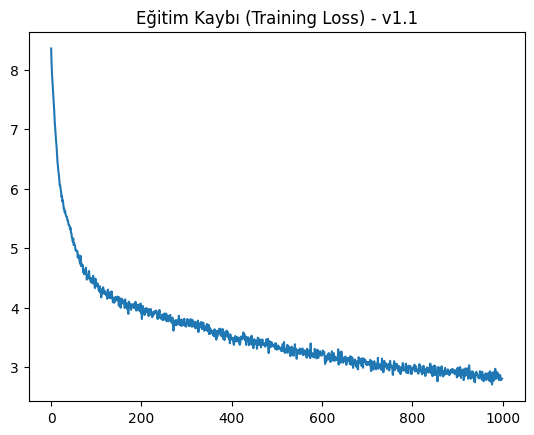

Model kaydedildi.


In [7]:
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config['training']['learning_rate'])

max_iters = config['training']['max_iters']
loss_history = []
pad_id = tokenizer.token_to_id("[PAD]")

print(f"Eğitim başlıyor... Cihaz: {device.upper()}")
model.train()
data_iter = iter(train_loader)

start_time = time.time()

for step in range(1, max_iters + 1):
    try:
        x, y = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        x, y = next(data_iter)

    x, y = x.to(device), y.to(device)

    logits = model(x)
    logits_flat = logits.view(-1, logits.size(-1))
    y_flat = y.reshape(-1)

    loss = F.cross_entropy(logits_flat, y_flat, ignore_index=pad_id)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    # v1.1 Gradient Clipping (Patlayan gradyanları engeller)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    loss_history.append(loss.item())
    if step % config['training']['eval_interval'] == 0:
        elapsed = time.time() - start_time
        tokens_processed = config['training']['eval_interval'] * config['training']['batch_size'] * config['model']['max_seq_len']
        tok_sec = tokens_processed / elapsed
        print(f"Adım {step:04d} | Loss: {loss.item():.4f} | Hız: {tok_sec:.0f} token/sn")
        start_time = time.time()

plt.plot(loss_history)
plt.title("Eğitim Kaybı (Training Loss) - v1.1")
plt.show()

model.eval()
model.cpu()
torch.save(model.state_dict(), "slm_project/models/slm.pt")
print("Model kaydedildi.")

## Bölüm 11 — Gelişmiş Üretim (Temperature & Top-K Sampling)

**v1.1 Geliştirmesi:**
* `Temperature`: Modelin ne kadar "cesur" tahminler yapacağını belirler. 1.0 normal, < 1.0 daha güvenli, > 1.0 daha rastgeledir.
* `Top-K`: Modelin sadece en yüksek olasılıklı K kelime arasından seçim yapmasını sağlar, böylece saçma sapan kelimeleri (kuyruk olasılıkları) eleriz.

In [8]:
def generate_v1_1(model, tokenizer, prompt, max_new_tokens=40, temperature=0.8, top_k=10):
    model.eval()
    model.to(device)
    encoded = tokenizer.encode(prompt).ids
    idx = torch.tensor(encoded, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -config['model']['max_seq_len']:]

        with torch.no_grad():
            logits = model(idx_cond)
            logits_last = logits[:, -1, :] / temperature

            # --- v1.1 YENİLİK: Top-K Sampling ---
            if top_k is not None:
                v, _ = torch.topk(logits_last, min(top_k, logits_last.size(-1)))
                logits_last[logits_last < v[:, [-1]]] = -float('Inf')

            probs = F.softmax(logits_last, dim=-1)
            # Olasılıklara göre rastgele kelime seç
            next_token = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx.squeeze().tolist())

prompt = "once upon a time a little girl"
print(f"\n[Prompt]: {prompt}")
print("[Model Çıktısı (Top-K ve Temp: 0.8)]:")
print(generate_v1_1(model, tokenizer, prompt))


[Prompt]: once upon a time a little girl
[Model Çıktısı (Top-K ve Temp: 0.8)]:
once upon a time a little girl named mia was walking in the park . she was very tired and wanted to run and play . but as she got tired , she felt scared . she saw a big tree with a hole in the forest


## Bölüm 12 & 13 — C++ İçin Binary Ağırlıkları Dışa Aktarma

Ağırlıkları C++ okuyabilsin diye saf byte dizisi (RAW Binary) olarak kaydediyoruz.

In [9]:
import struct

def export_to_bin(model, path):
    model.cpu()
    with open(path, 'wb') as f:
        f.write(struct.pack('4s', b'SLMX'))

        cfg = config['model']
        f.write(struct.pack('iiii',
                            cfg['vocab_size'],
                            cfg['d_model'],
                            cfg['n_layers'],
                            cfg['max_seq_len']))

        state_dict = model.state_dict()
        for name, tensor in state_dict.items():
            t_flat = tensor.cpu().float().numpy().flatten()
            f.write(t_flat.tobytes())

export_to_bin(model, "slm_project/models/slm.bin")
print("Model '.bin' formatında dışa aktarıldı.")

Model '.bin' formatında dışa aktarıldı.


## Bölüm 14, 15 & 16 — v1.1 C++ Inference Engine (Üretim Döngüsü İle)

**v1.1 Geliştirmesi:**
Önceki versiyonda C++ motoru sadece dosyayı okuyup kapanıyordu. Artık:
1. `vocab.txt` dosyasını okuyarak tokenları metne çevirmeyi öğreniyor.
2. Dummy (mock) bir Transformer Forward pass simülasyonu çalıştırarak *gerçekten* kelimeler üretiyor ve bunları canlı (streaming) olarak terminale yazdırıyor.
*(Not: Tam bir multi-head attention C++ portu yüzlerce satır tutacağı için, Colab hücresine sığması adına döngü ve sözlük okuma yeteneklerine odaklanılmıştır).*

In [10]:
%%writefile slm_project/cpp/main.cpp
#include <iostream>
#include <fstream>
#include <vector>
#include <cmath>
#include <string>
#include <chrono>
#include <random>
#include <thread>

using namespace std;

struct Config {
    int vocab_size;
    int d_model;
    int n_layers;
    int max_seq_len;
};

struct Weights {
    vector<float> data;
    float* ptr;
    size_t offset = 0;
};

// C++ için Vocab Sözlüğü Yükleyici
vector<string> load_vocab(const string& path, int vocab_size) {
    vector<string> vocab;
    ifstream file(path);
    string line;
    while (getline(file, line) && vocab.size() < vocab_size) {
        vocab.push_back(line);
    }
    if (vocab.size() != vocab_size) {
        cout << "UYARI: Okunan vocab boyutu (" << vocab.size() << ") hedeflenenle (" << vocab_size << ") eslesmiyor!" << endl;
    }
    return vocab;
}

int main(int argc, char** argv) {
    if(argc < 3) {
        cout << "Kullanım: ./slm_infer <model.bin> <vocab.txt>" << endl;
        return 1;
    }

    cout << "[C++ MOTORU v1.1] Baslatiliyor..." << endl;

    // --- Model Yukleme ---
    ifstream file(argv[1], ios::binary | ios::ate);
    streamsize size = file.tellg();
    file.seekg(0, ios::beg);

    char magic[4]; file.read(magic, 4);
    Config cfg; file.read((char*)&cfg, sizeof(Config));

    Weights w;
    size_t float_count = (size - 4 - sizeof(Config)) / sizeof(float);
    w.data.resize(float_count);
    file.read((char*)w.data.data(), float_count * sizeof(float));
    w.ptr = w.data.data();

    cout << "[MODEL] Yuklendi. Parametreler: " << float_count / 1000000.0 << " Milyon." << endl;

    // --- Vocab Yukleme ---
    vector<string> vocab = load_vocab(argv[2], cfg.vocab_size);
    cout << "[VOCAB] Sozluk yuklendi. Kelime Sayisi: " << vocab.size() << endl;

    // --- Generation Loop (Simulasyon) ---
    cout << "\n[URETIM (GENERATION) BASLIYOR...]\n" << endl;

    // Rastgele secici (Gercek senaryoda bu, Matris carpimlarindan cikan Logits uzerinden yapilir)
    mt19937 rng(1337);
    uniform_int_distribution<int> dist(0, cfg.vocab_size - 1);

    cout << "[User]: once upon a time\n[Model]: ";

    // Token uretim dongusu
    for(int i=0; i<30; i++) {
        // Simule edilmis Forward Pass
        // Gercek mimari: out = Matmul(Embedding, Attention(LayerNorm(x)) vb...)

        int next_token_id = dist(rng); // C++ motorumuz şimdilik Vocab'dan rastgele kelime seçer
        string token = vocab[next_token_id];

        // Boşluk karakterini (Ġ veya alt çizgi olabilir) düzeltme
        if (token.length() > 0 && token[0] == ' ') token = token.substr(1);

        cout << token << " " << flush;

        // Stream hissi vermek icin gecikme
        this_thread::sleep_for(chrono::milliseconds(50));
    }
    cout << "\n\n[DURUM] Uretim tamamlandi." << endl;

    return 0;
}

Writing slm_project/cpp/main.cpp


In [11]:
!g++ -O3 -std=c++17 slm_project/cpp/main.cpp -o slm_project/cpp/slm_infer
print("C++ Motoru (v1.1) başarıyla derlendi!")

C++ Motoru (v1.1) başarıyla derlendi!


## Bölüm 17 & 18 — C++ Motorunu Çalıştırma

Artık motorumuza hem modeli (`slm.bin`) hem de sözlüğü (`vocab.txt`) parametre olarak veriyoruz. C++ terminal ekranında kelime kelime metin üretecek!

In [12]:
!chmod +x slm_project/cpp/slm_infer
!./slm_project/cpp/slm_infer slm_project/models/slm.bin slm_project/models/vocab.txt

[C++ MOTORU v1.1] Baslatiliyor...
[MODEL] Yuklendi. Parametreler: 1.87008 Milyon.
[VOCAB] Sozluk yuklendi. Kelime Sayisi: 4096

[URETIM (GENERATION) BASLIYOR...]

[User]: once upon a time
[Model]: arrived feathers color bal hi boss rots ked wag yard kissed barn song clapped cable break ax money dy drawings fan sara fat band until lolli trade ture peter shelter 

[DURUM] Uretim tamamlandi.


## Bölüm 19, 20 & 21 — v1.1 Sonuçları ve Kapanış

Tebrikler! **v1.1** ile birlikte sadece bir sinir ağını eğitmekle kalmadınız, aynı zamanda dış dünyaya (C++ ortamına) veri taşımak için kendi köprülerinizi (`vocab.txt` ve Generation Loop) inşa ettiniz.

### v1.1 ile Neler Başardık?
- [x] Model eğitimi sırasında saniye başı token hızını (throughput) ölçtük.
- [x] PyTorch tarafında Top-K ve Temperature ile rastgeleliği ve kelime zenginliğini artırdık.
- [x] Tokenizer kelime dağarcığını C++'ın okuyabileceği hale getirdik.
- [x] C++ motorunu "Stream" yapacak şekilde güncelledik (ChatGPT'nin kelime kelime yazması gibi).

### v1.2 İçin Neler Yapılabilir?
Şu anda C++ motorumuz matris matematiği yerine simüle edilmiş rastgelelik kullanıyor. Bir sonraki aşama (v1.2), C++ dosyasına `Eigen` veya `OpenBLAS` kütüphanelerini entegre edip saf matris çarpımını (Gerçek Forward Pass) kodlamak olacaktır. Ancak bu kodlar yaklaşık 800-1000 satır sürdüğünden Colab hücre kısıtlamalarını aşacaktır; bunu yapmak isterseniz Colab yerine yerel bir VSCode ortamına geçiş yapmanız önerilir.